# **Treadmill Buyer Profile**

**Link**: [https://platform.stratascratch.com/data-projects/treadmill-buyer-profile](https://platform.stratascratch.com/data-projects/treadmill-buyer-profile) \
**Difficulty**: Easy

## **Description**

This data project has been used as a take-home assignment in the recruitment process for the data science positions at Aerofit.

## **Assignment**

The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to new customers. The team decides to investigate whether there are differences across the product with respect to customer characteristics.

Perform descriptive analytics to create a customer profile for each AeroFit treadmill product by developing appropriate tables and charts. For each AeroFit treadmill product, construct two-way contingency tables and compute all conditional and marginal probabilities along with their insights/impact on the business.

Product Portfolio:

- The KP281 is an entry-level treadmill that sells for $1,500;
- The KP481 is for mid-level runners and sells for $1,750;
- The KP781 treadmill is having advanced features and it sells for $2,500.

## **Data Exploration and Processing**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.color_palette("husl", 8)

import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")


### **Import Data**

In [3]:
aerofit_df = pd.read_csv('datasets/aerofit_treadmill_data.csv')
aerofit_df.head(10)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
5,KP281,20,Female,14,Partnered,3,3,32973,66
6,KP281,21,Female,14,Partnered,3,3,35247,75
7,KP281,21,Male,13,Single,3,3,32973,85
8,KP281,21,Male,15,Single,5,4,35247,141
9,KP281,21,Female,15,Partnered,2,3,37521,85


In [4]:
aerofit_df.shape

(180, 9)

In [5]:
aerofit_df.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')

In [7]:
aerofit_df.dtypes

Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object

The DataFrame has columns containing the datatype object. Since each such column only includes a set of predetermined labels, we can convert the datatype to ```category```.

In [8]:
aerofit_df['Product'] = aerofit_df['Product'].astype('category')
aerofit_df['Gender'] = aerofit_df['Gender'].astype('category')
aerofit_df['MaritalStatus'] = aerofit_df['MaritalStatus'].astype('category')
aerofit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    category
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    category
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    category
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    int64   
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
dtypes: category(3), int64(6)
memory usage: 9.5 KB


In [11]:
numerical_cols = aerofit_df.select_dtypes(include='int64')
numerical_cols.skew()

Age          0.982161
Education    0.622294
Usage        0.739494
Fitness      0.454800
Income       1.291785
Miles        1.724497
dtype: float64

### Statistical Summary

In [13]:
aerofit_df.describe(include = 'all')

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


**Observations**:

- There are no missing values in the data.
- There are 3 unique products in the dataset.
- ```KP281``` is the most frequent product.
- Minimum & Maximum age of the person is 18 & 50, mean is 28.79, and 75% of persons have an age less than or equal to 33.
- Most of the people are having 16 years of education i.e. 75% of persons are having education <= 16 years.
- Out of 180 data points, 104's gender is Male and rest are the Female.
- Standard deviation for Income & Miles is very high. These variables might have outliers in them.

### Missing value detection

In [14]:
def missing_data(input_data):
    total = input_data.isnull().sum()
    percent = (input_data.isnull().sum() / input_data.isnull().count() * 100)
    table = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
    types = []
    for col in input_data.columns: 
        dtype = str(input_data[col].dtype)
        types.append(dtype)
    table["Types"] = types
    return(pd.DataFrame(table))

missing_data(aerofit_df)

,Total,Percent,Types
Product,0,0.0,category
Age,0,0.0,int64
Gender,0,0.0,category
Education,0,0.0,int64
MaritalStatus,0,0.0,category
Usage,0,0.0,int64
Fitness,0,0.0,int64
Income,0,0.0,int64
Miles,0,0.0,int64


In [15]:
aerofit_df.duplicated(subset=None,keep='first').sum()

0

## **Non-Graphical Analysis**

### **Value Counts**

In [16]:
aerofit_df["Product"].value_counts()

Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

In [17]:
aerofit_df["Gender"].value_counts()

Gender
Male      104
Female     76
Name: count, dtype: int64

In [18]:
aerofit_df["MaritalStatus"].value_counts()

MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64

### Unique Attributes

In [19]:
aerofit_df.nunique()

Product           3
Age              32
Gender            2
Education         8
MaritalStatus     2
Usage             6
Fitness           5
Income           62
Miles            37
dtype: int64

In [20]:
aerofit_df["Product"].unique()

['KP281', 'KP481', 'KP781']
Categories (3, object): ['KP281', 'KP481', 'KP781']

In [21]:
aerofit_df["Age"].unique()

array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 50, 45, 48, 42],
      dtype=int64)

In [22]:
aerofit_df["Gender"].unique()

['Male', 'Female']
Categories (2, object): ['Female', 'Male']

In [23]:
aerofit_df["Education"].unique()

array([14, 15, 12, 13, 16, 18, 20, 21], dtype=int64)

In [24]:
aerofit_df["MaritalStatus"].unique()

['Single', 'Partnered']
Categories (2, object): ['Partnered', 'Single']

In [25]:
aerofit_df["Usage"].unique()

array([3, 2, 4, 5, 6, 7], dtype=int64)

In [26]:
aerofit_df["Income"].unique()

array([ 29562,  31836,  30699,  32973,  35247,  37521,  36384,  38658,
        40932,  34110,  39795,  42069,  44343,  45480,  46617,  48891,
        53439,  43206,  52302,  51165,  50028,  54576,  68220,  55713,
        60261,  67083,  56850,  59124,  61398,  57987,  64809,  47754,
        65220,  62535,  48658,  54781,  48556,  58516,  53536,  61006,
        57271,  52291,  49801,  62251,  64741,  70966,  75946,  74701,
        69721,  83416,  88396,  90886,  92131,  77191,  52290,  85906,
       103336,  99601,  89641,  95866, 104581,  95508], dtype=int64)

In [27]:
aerofit_df["Fitness"].unique()

array([4, 3, 2, 1, 5], dtype=int64)

In [28]:
aerofit_df["Miles"].unique()

array([112,  75,  66,  85,  47, 141, 103,  94, 113,  38, 188,  56, 132,
       169,  64,  53, 106,  95, 212,  42, 127,  74, 170,  21, 120, 200,
       140, 100,  80, 160, 180, 240, 150, 300, 280, 260, 360], dtype=int64)

## **Graphical Analysis**

### Univariate Analysis - Numerical Variables

**Distance Plot**

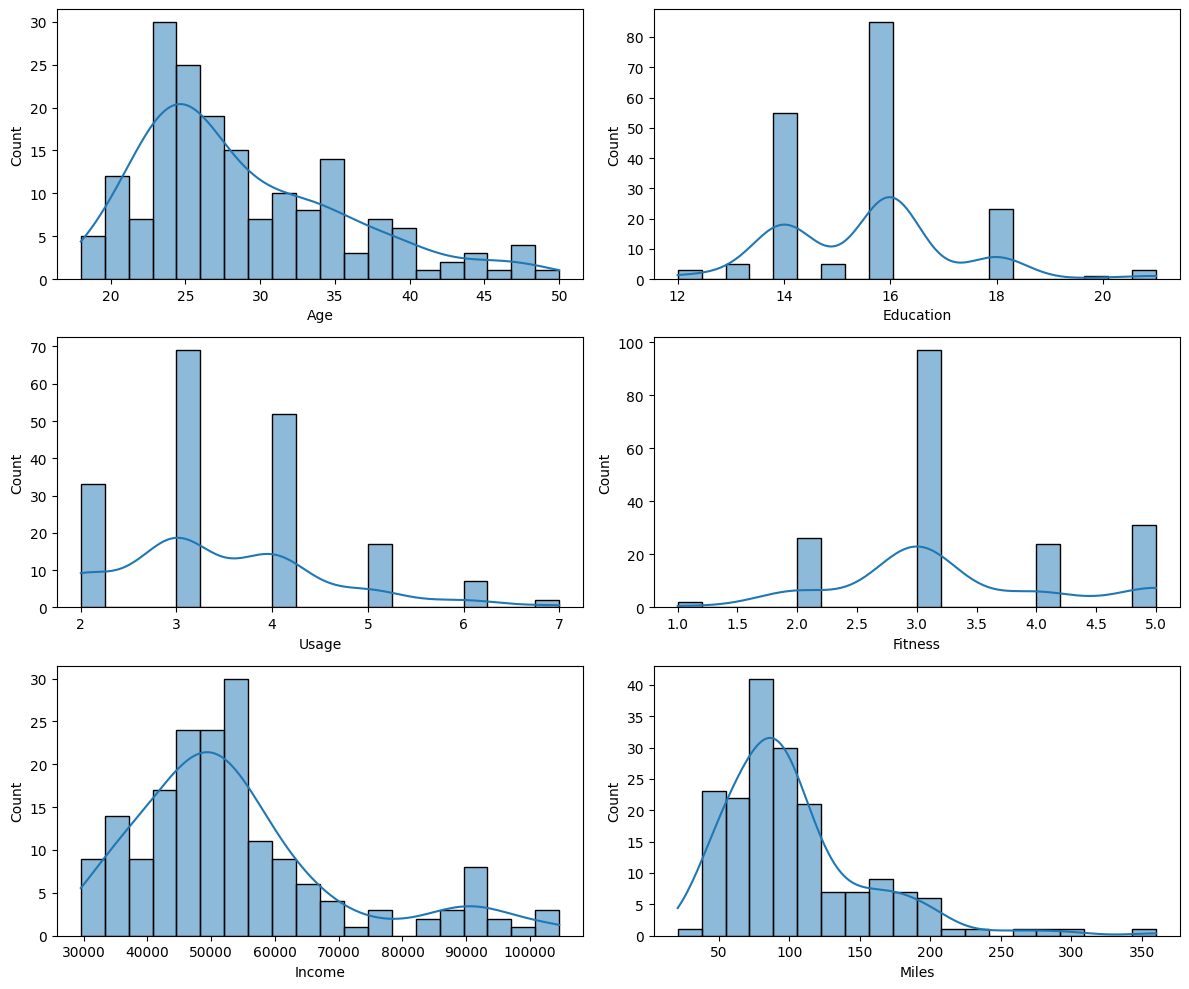

In [30]:
fig, axis = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.subplots_adjust(top=1.2)

sns.histplot(aerofit_df['Age'], kde=True, ax=axis[0,0], bins=20)
sns.histplot(aerofit_df['Education'], kde=True, ax=axis[0,1], bins=20)
sns.histplot(aerofit_df['Usage'], kde=True, ax=axis[1,0], bins=20)
sns.histplot(aerofit_df['Fitness'], kde=True, ax=axis[1,1], bins=20)
sns.histplot(aerofit_df['Income'], kde=True, ax=axis[2,0], bins=20)
sns.histplot(aerofit_df['Miles'], kde=True, ax=axis[2,1], bins=20)

plt.tight_layout()
plt.show()

**Observations**:

- Both ```Miles``` and ```Income``` have significant outliers based on the above distribution.
- Also ```Miles``` and ```Income``` are "right-skewed distribution" which means the mass of the distribution is concentrated on the left of the figure.
- Customer with fitness level 3 buy a major chuck of treadmills.
- Majority of Customers fall within the ```$ 45,000 - $ 60,000``` income range

**Count Plot**

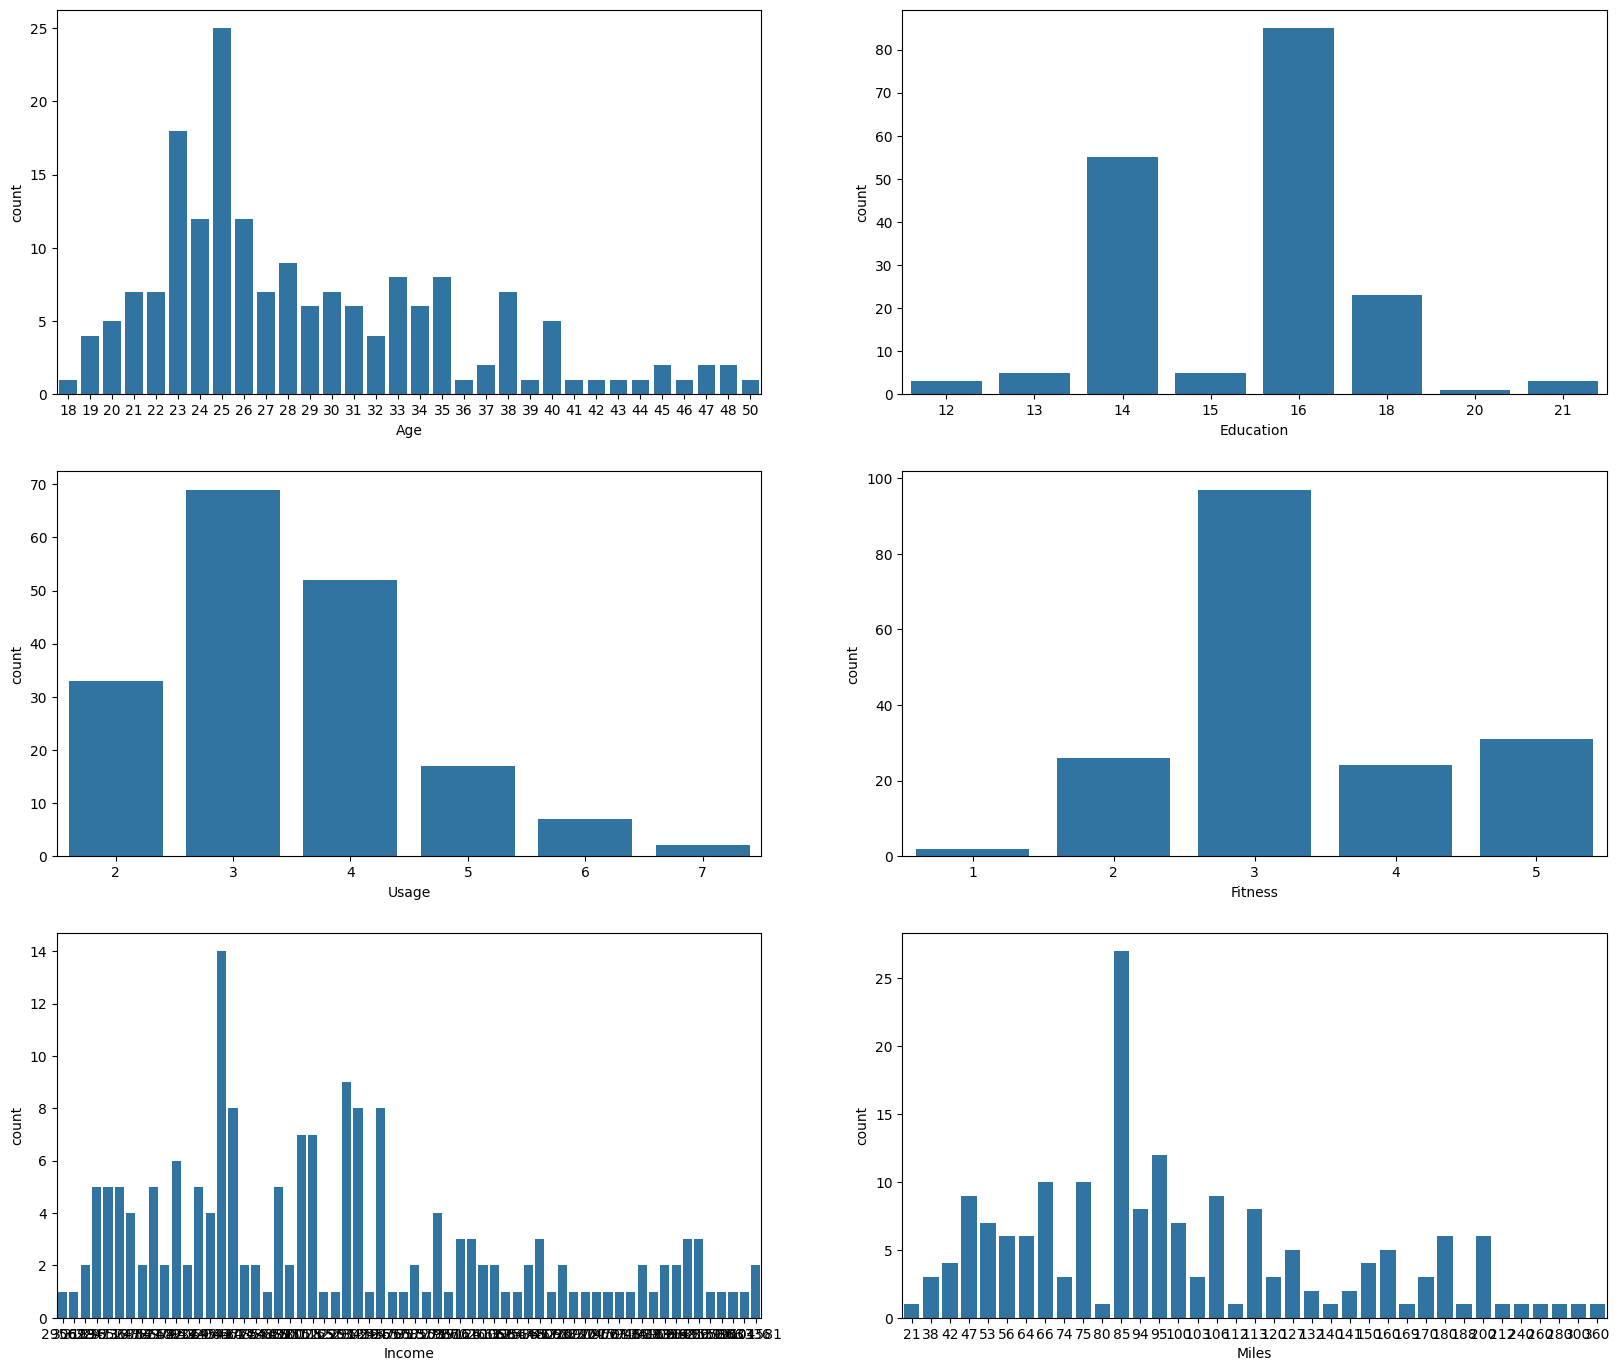

In [31]:
fig, axis = plt.subplots(nrows=3, ncols=2, figsize=(20, 12))
fig.subplots_adjust(top=1.2)

sns.countplot(data=aerofit_df, x="Age", ax=axis[0,0])
sns.countplot(data=aerofit_df, x="Education", ax=axis[0,1])
sns.countplot(data=aerofit_df, x="Usage", ax=axis[1,0])
sns.countplot(data=aerofit_df, x="Fitness", ax=axis[1,1])
sns.countplot(data=aerofit_df, x="Income", ax=axis[2,0])
sns.countplot(data=aerofit_df, x="Miles", ax=axis[2,1])
plt.show()

**Observations**:

- Young people at ```age``` of 25 are more conscious about health and are using treadmills more than old aged people.

**Box Plot**

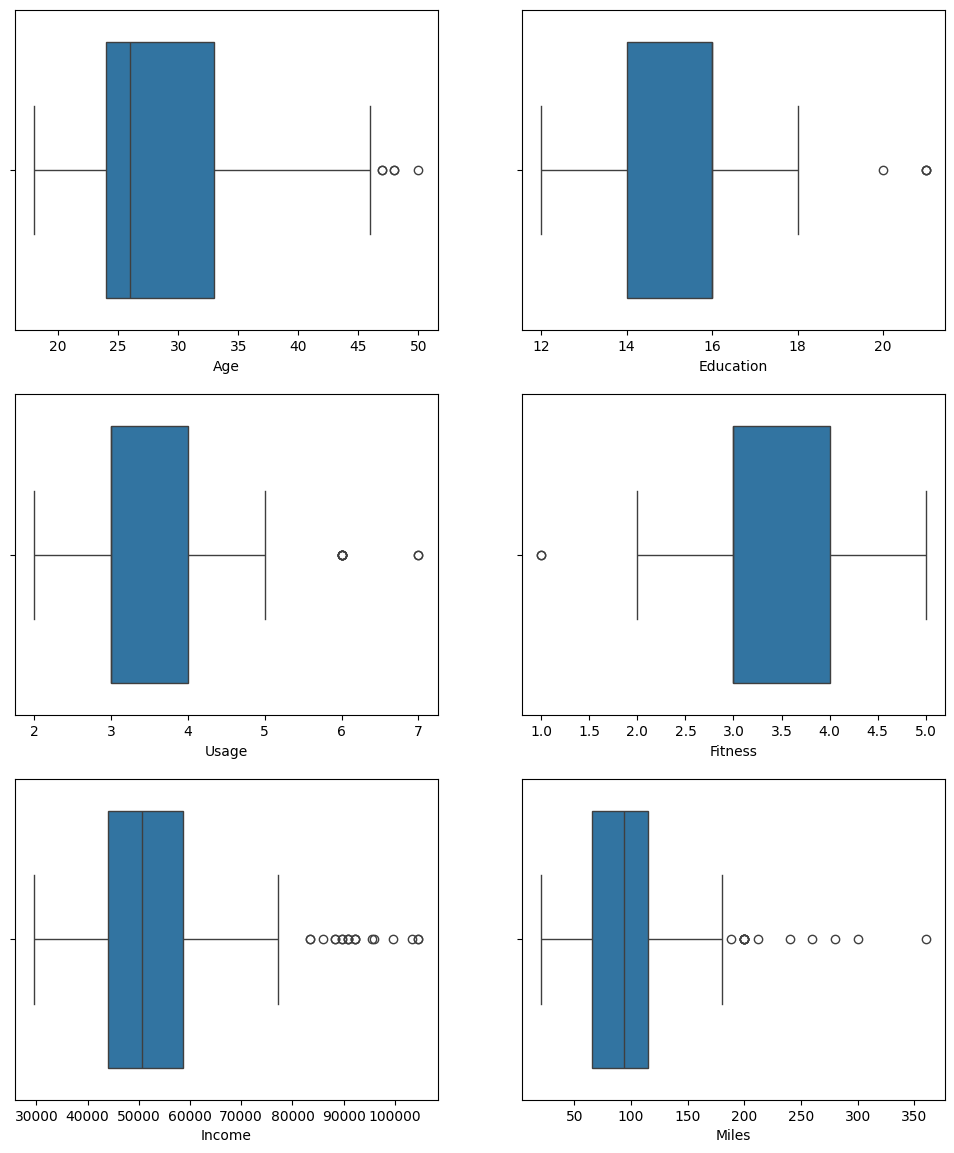

In [32]:
fig, axis = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.subplots_adjust(top=1.2)

sns.boxplot(data=aerofit_df, x="Age", orient='h', ax=axis[0,0])
sns.boxplot(data=aerofit_df, x="Education", orient='h', ax=axis[0,1])
sns.boxplot(data=aerofit_df, x="Usage", orient='h', ax=axis[1,0])
sns.boxplot(data=aerofit_df, x="Fitness", orient='h', ax=axis[1,1])
sns.boxplot(data=aerofit_df, x="Income", orient='h', ax=axis[2,0])
sns.boxplot(data=aerofit_df, x="Miles", orient='h', ax=axis[2,1])
plt.show()

**Observations**:

- ```Age```, ```Education```, and ```Usage``` have very few outliers.
- While ```Income``` and ```Miles``` have more outliers.

### Univariate Analysis - Categorical Variables

**Count Plot**

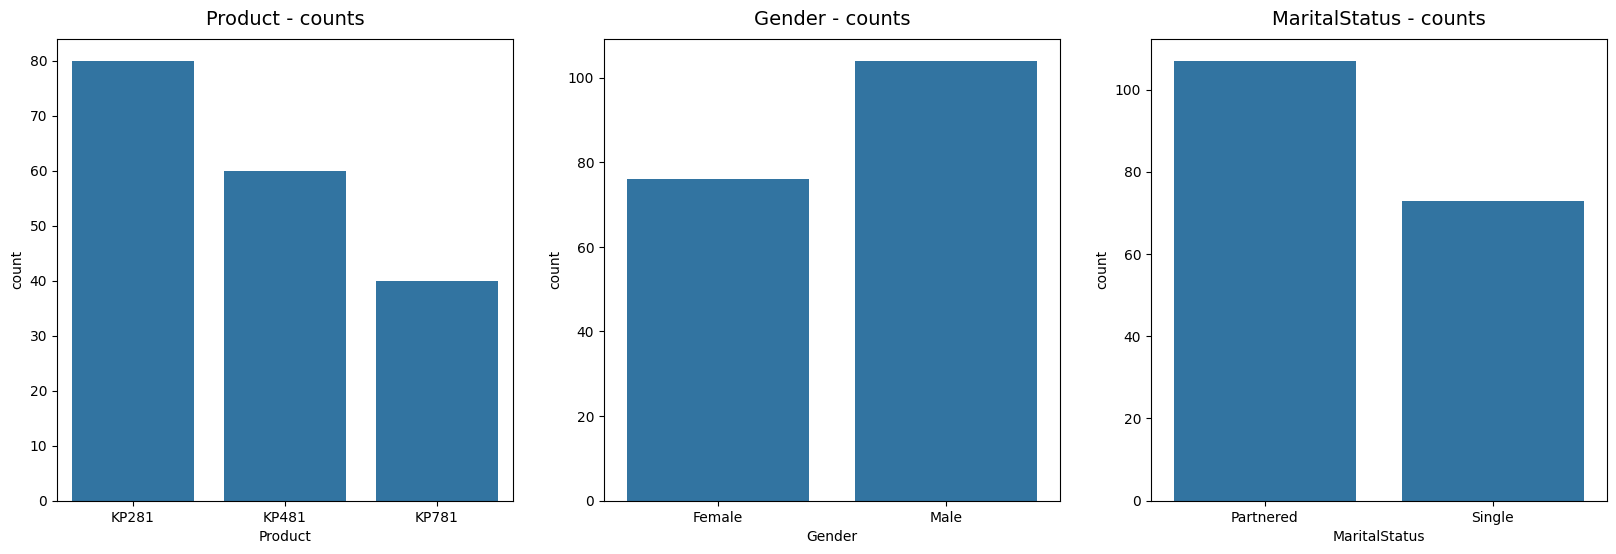

In [33]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
sns.countplot(data=aerofit_df, x='Product', ax=axs[0])
sns.countplot(data=aerofit_df, x='Gender', ax=axs[1])
sns.countplot(data=aerofit_df, x='MaritalStatus', ax=axs[2])

axs[0].set_title("Product - counts", pad=10, fontsize=14)
axs[1].set_title("Gender - counts", pad=10, fontsize=14)
axs[2].set_title("MaritalStatus - counts", pad=10, fontsize=14)
plt.show()

**Observations**

- ```KP281``` is the most frequent product and best-selling product.
- In ```Gender```, there are more ```Males``` who are using treadmills than ```Females```.
- The treadmills are more likely to be purchased by ```partnered``` people

### Bivariate Analysis

Checking if features have any effect on the product purchased.

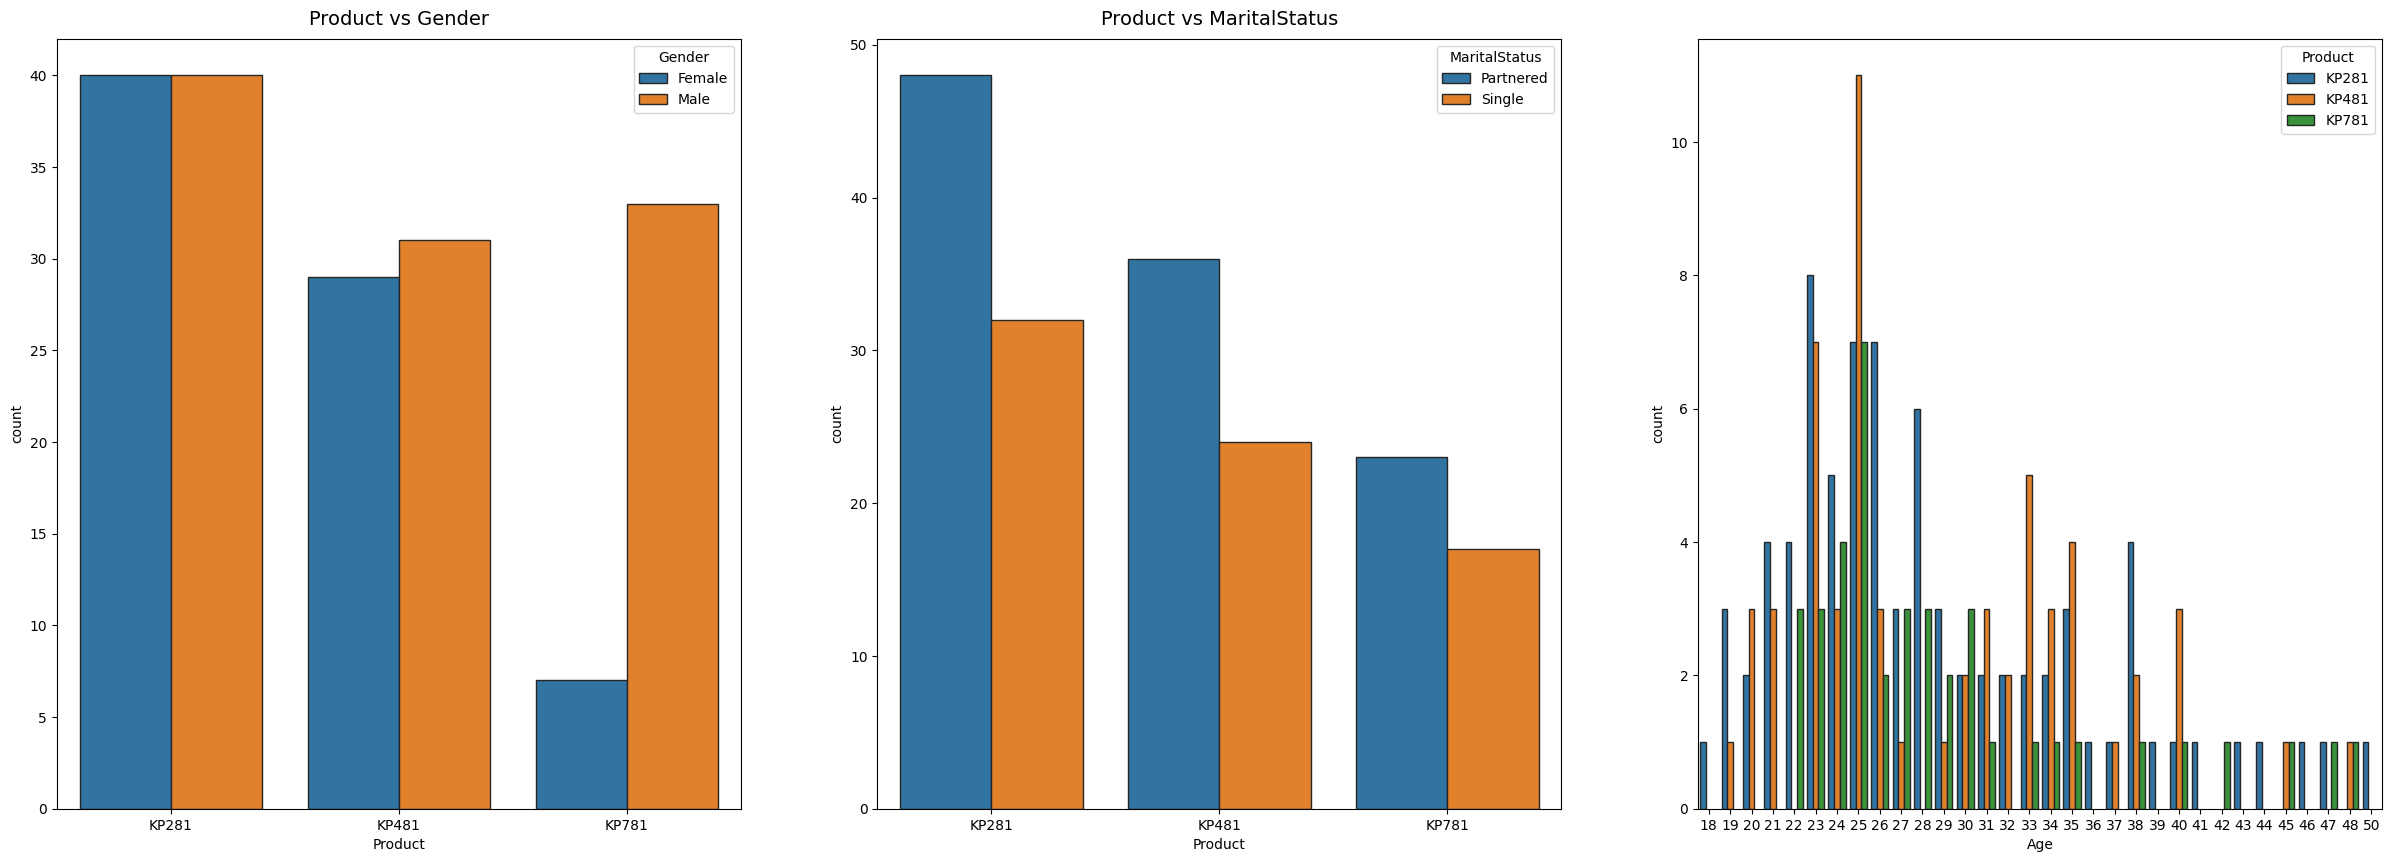

In [34]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
sns.countplot(data=aerofit_df, x='Product', hue='Gender', edgecolor="0.15", ax=axs[0])
sns.countplot(data=aerofit_df, x='Product', hue='MaritalStatus', edgecolor="0.15", ax=axs[1])
sns.countplot(data=aerofit_df, x='Age', hue='Product', edgecolor="0.15", ax=axs[2])
axs[0].set_title("Product vs Gender", pad=10, fontsize=14)
axs[1].set_title("Product vs MaritalStatus", pad=10, fontsize=14)
plt.show()

**Obervations**

- **Product vs Gender**
    - Equal number of males and females have purchased KP281 product and Almost same for the product KP481
    - Most of the Male customers have purchased the KP781 product.

- **Product vs MaritalStatus**

    - Customer who is Partnered, is more likely to purchase the product.

- **Age vs Product**

    - Customers with age of 25 are more likely to purchase the KP481 product.

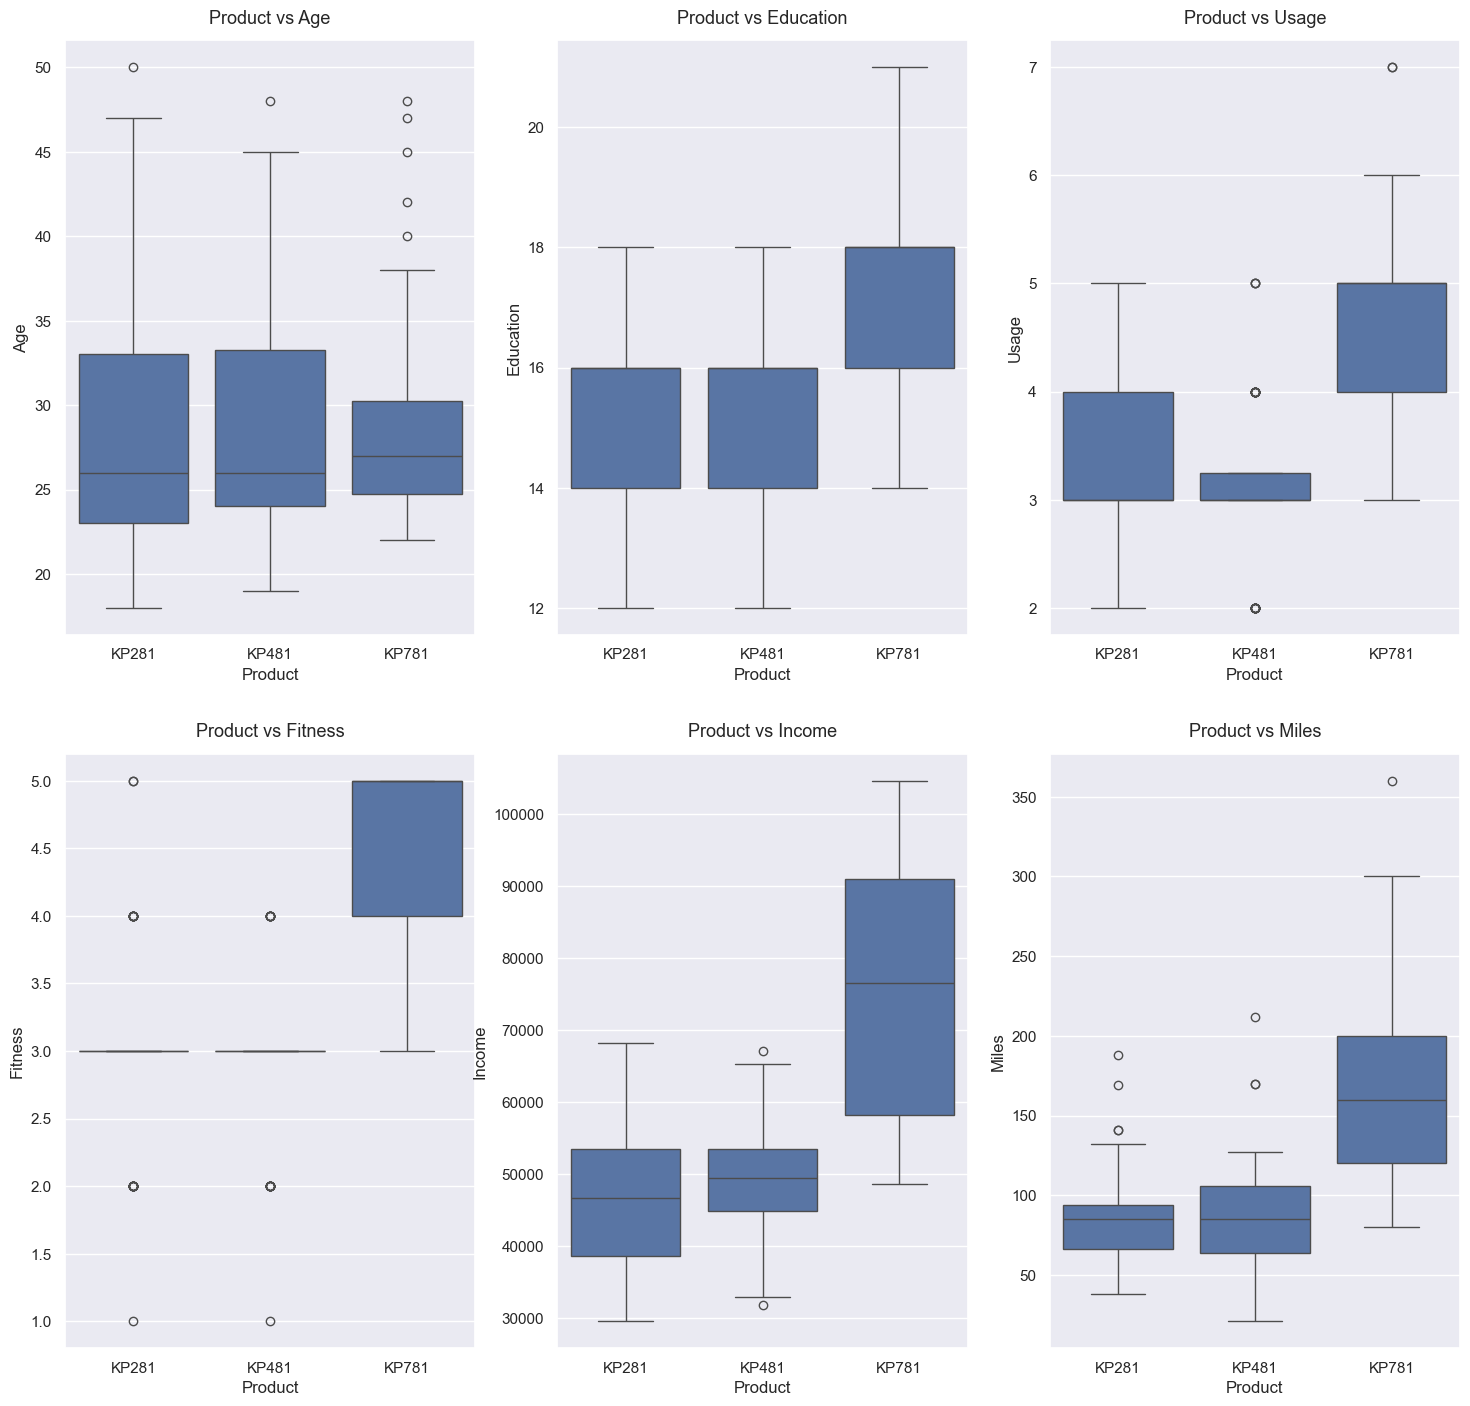

In [35]:
attributes = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
sns.set(color_codes = True)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.subplots_adjust(top=1.2)
count = 0
for i in range(2):
    for j in range(3):
        sns.boxplot(data=aerofit_df, x='Product', y=attributes[count], ax=axs[i,j])
        axs[i,j].set_title(f"Product vs {attributes[count]}", pad=12, fontsize=13)
        count += 1

**Observations**:

- **Product vs Age**
    - Customers purchasing products ```KP281 & KP481``` are having same ```Age``` median value.
    - Customers whose age lies between 25-30, are more likely to buy the ```KP781``` product

- **Product vs Education**
    - Customers whose Education is greater than 16, have more chances to purchase the KP781 product.
    - While the customers with Education less than 16 have equal chances of purchasing KP281 or KP481.

- **Product vs Usage**
    - Customers who are planning to use the treadmill greater than 4 times a week, are more likely to purchase the KP781 product.
    - While the other customers are likely to purchase KP281 or KP481.
    
- **Product vs Fitness**
    - The more the customer is fit (fitness >= 3), the higher the chances of the customer purchasing the KP781 product.

- **Product vs Income**
    - The higher the Income of the customer (Income >= 60000), the higher the chances of the customer purchasing the KP781 product.

- **Product vs Miles**
    - If the customer expects to walk/run greater than 120 Miles per week, it is more likely that the customer will buy the KP781 product.

### Multivariate Analysis

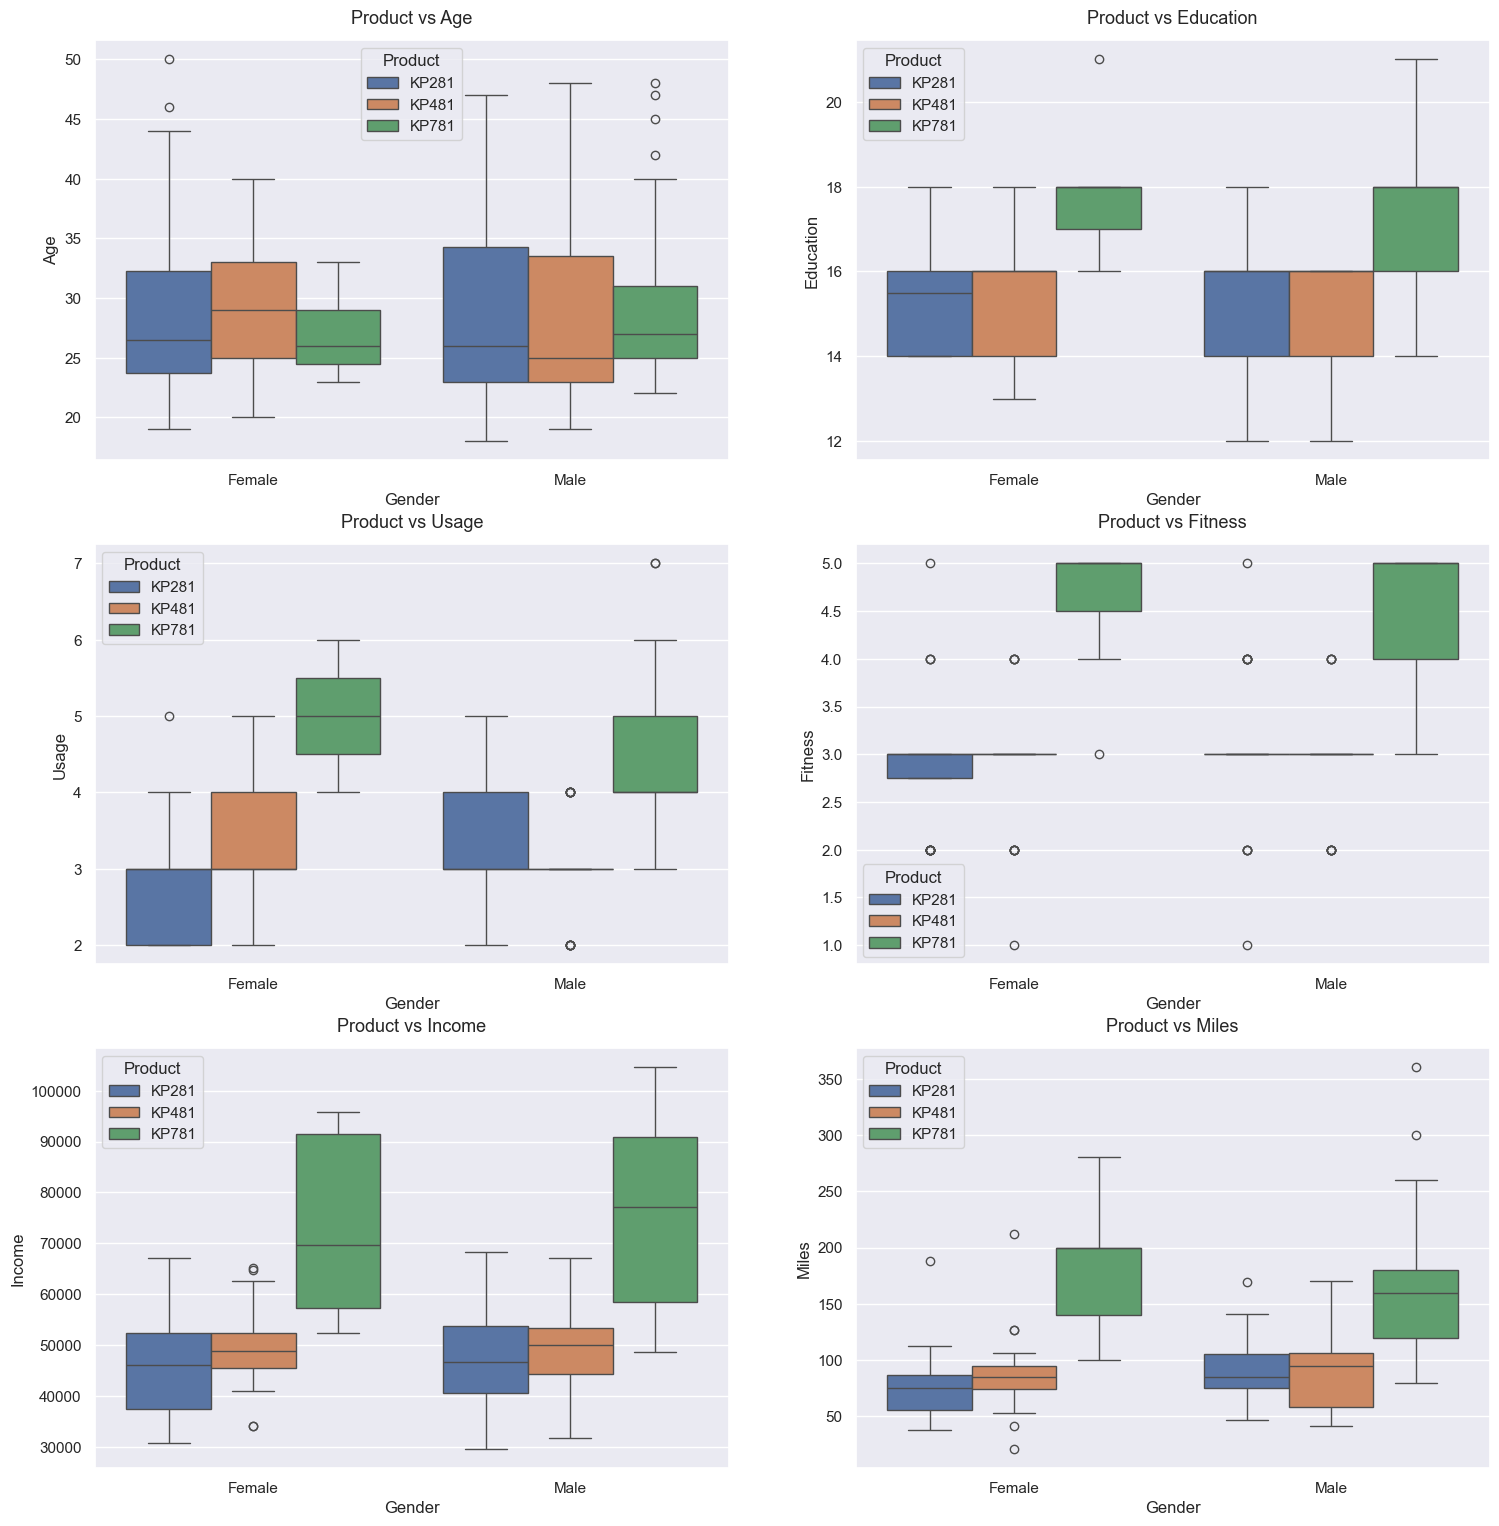

In [37]:
attributes = ['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']
sns.set_theme(color_codes = True)
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(18, 12))
fig.subplots_adjust(top=1.3)
count = 0
for i in range(3):
    for j in range(2):
        sns.boxplot(data=aerofit_df, x='Gender', y=attributes[count], hue='Product', ax=axs[i,j])
        axs[i,j].set_title(f"Product vs {attributes[count]}", pad=12, fontsize=13)
        count += 1

**Obervations**

- Females planning to use the treadmill 3-4 times a week, are more likely to buy the ```KP481``` product

### Correlation Analysis

In [39]:
numerical_cols.cov()

,Age,Education,Usage,Fitness,Income,Miles
Age,48.212166,3.149410,0.113470,0.406828,5.884446e+04,13.186530
Education,3.149410,2.614867,0.693172,0.636623,1.670472e+04,25.770795
Usage,0.113470,0.693172,1.176785,0.695469,9.303043e+03,42.709808
Fitness,0.406828,0.636623,0.695469,0.919429,8.467925e+03,39.073246
Income,58844.463439,16704.717815,9303.042582,8467.925388,2.724706e+08,465265.361887
Miles,13.186530,25.770795,42.709808,39.073246,4.652654e+05,2689.833489


In [40]:
numerical_cols.corr()

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.280496,0.015064,0.061105,0.513414,0.036618
Education,0.280496,1.000000,0.395155,0.410581,0.625827,0.307284
Usage,0.015064,0.395155,1.000000,0.668606,0.519537,0.759130
Fitness,0.061105,0.410581,0.668606,1.000000,0.535005,0.785702
Income,0.513414,0.625827,0.519537,0.535005,1.000000,0.543473
Miles,0.036618,0.307284,0.759130,0.785702,0.543473,1.000000


**Heatmaps**

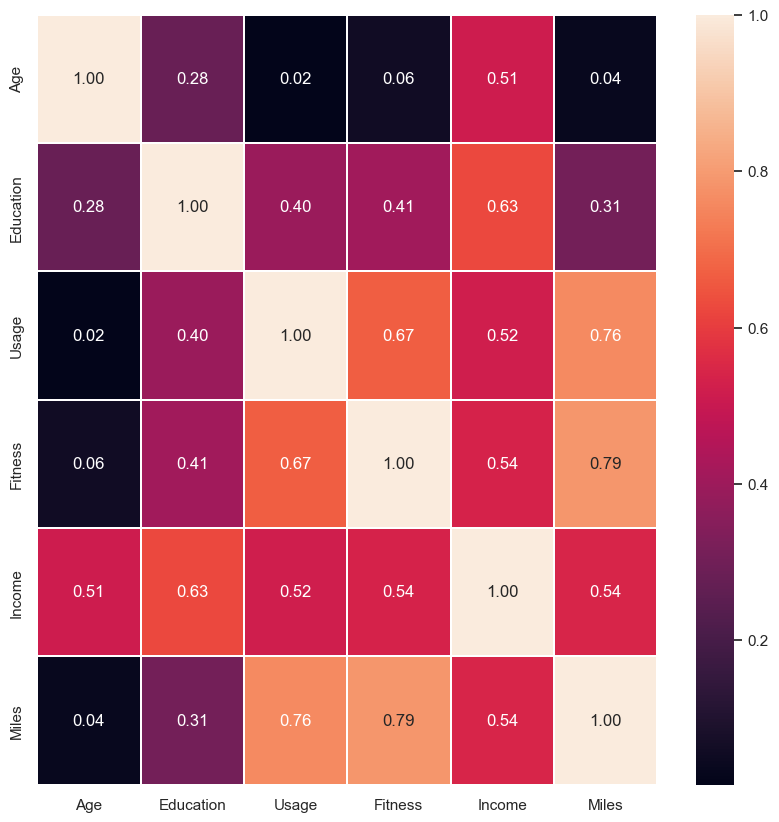

In [42]:
fig, ax = plt.subplots(figsize = (10,10))
sns.set(color_codes = True)
sns.heatmap(numerical_cols.corr(), ax=ax, annot = True, linewidths = 0.05, fmt ='0.2f')
plt.show()

**Observations**:

- (```Miles``` & ```Fitness```) and (```Miles``` & ```Usage```) attributes are highly correlated, which means if a customer's fitness level is high they use more treadmills.

- ```Income``` and ```Education``` shows a strong correlation. High-income and highly educated people prefer the ```KP781``` treadmill which is having advanced features.

- There is no correlation between (```Usage``` & ```Age```) or (```Fitness``` & ```Age```) attributes, which mean Age should not be a barrier to using treadmills or specific model of treadmills.

**Pair Plots**

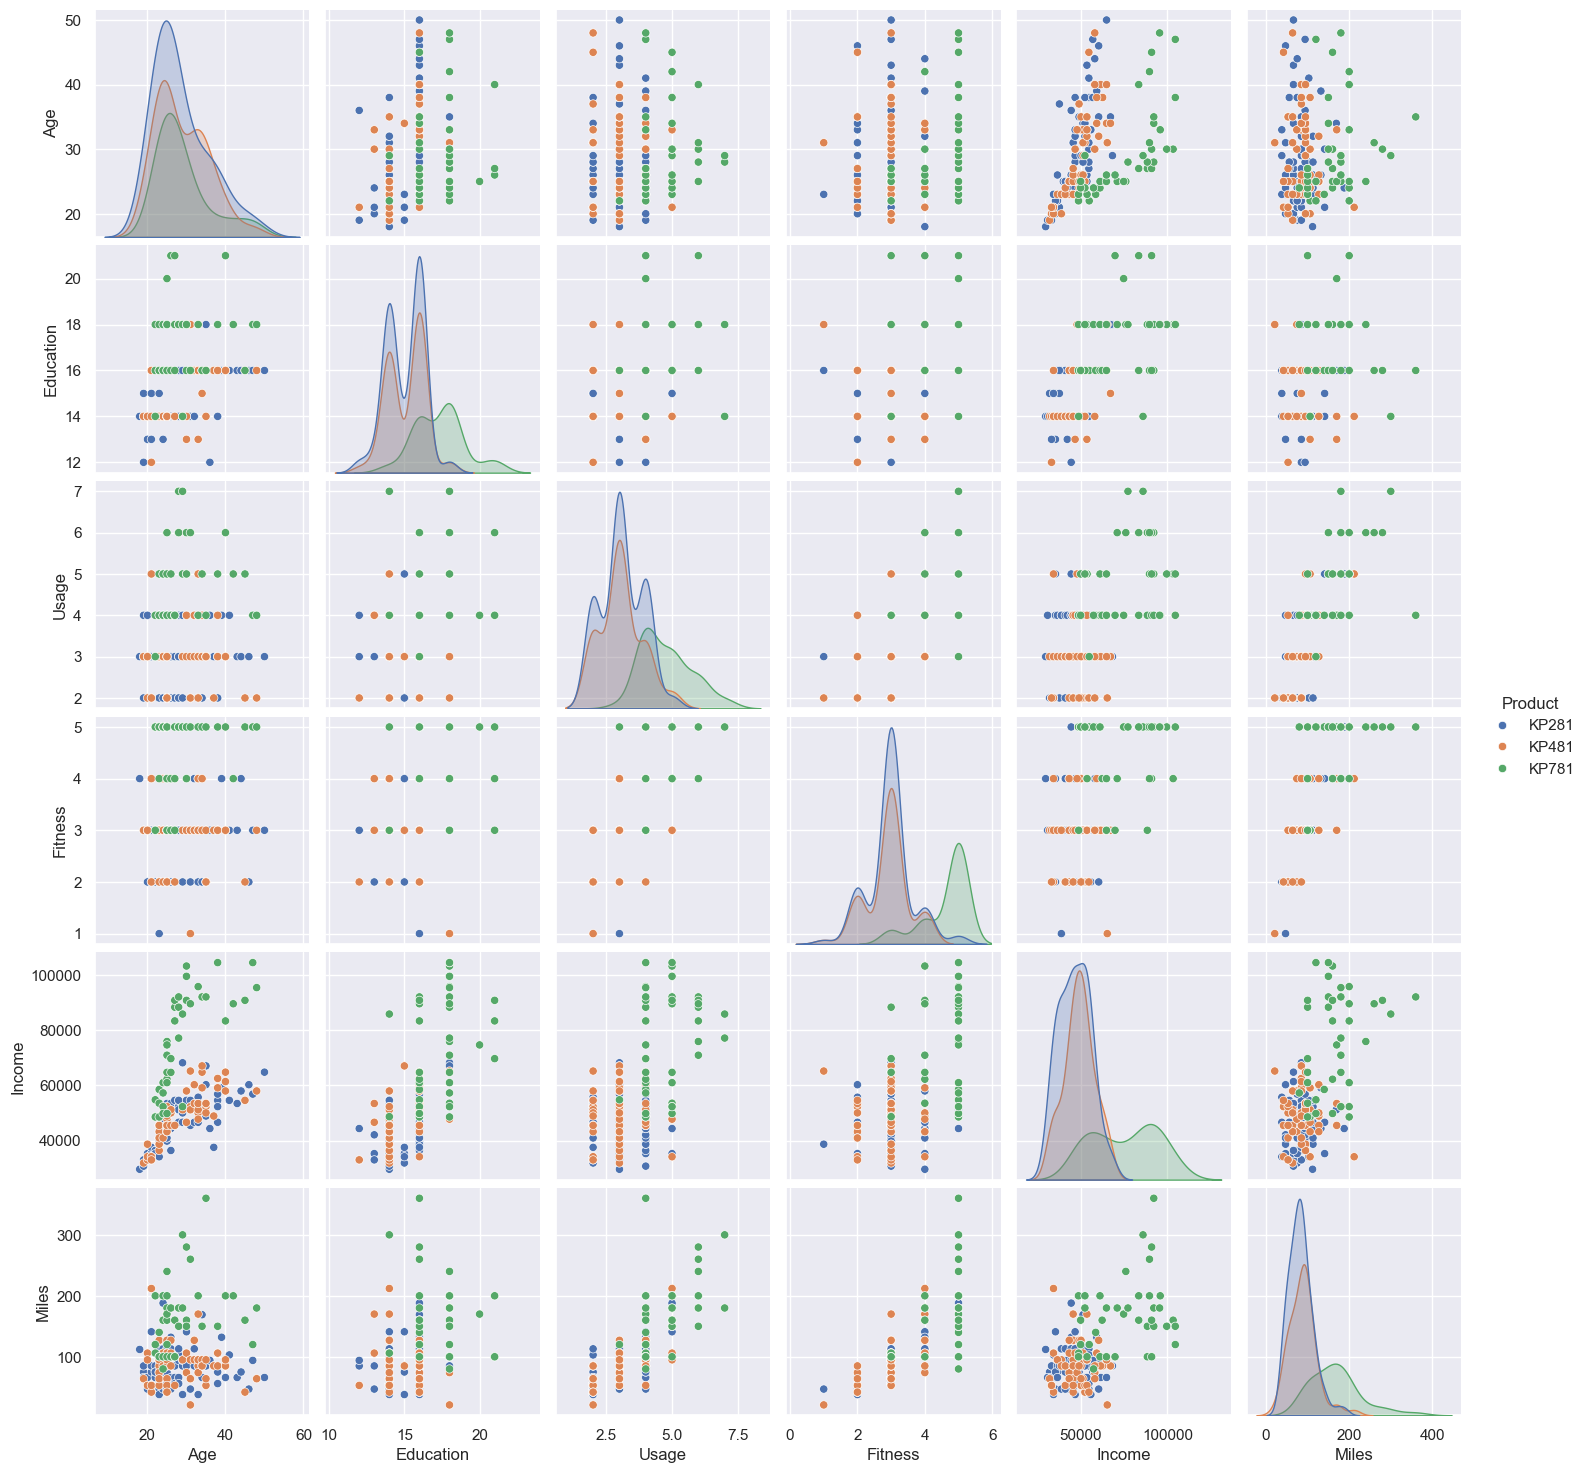

In [43]:
sns.pairplot(aerofit_df, hue = "Product")
plt.show()

## **Marginal & Conditional Probabilities**

What percent of customers have purchased KP281, KP481, or KP781?

In [44]:
aerofit_df1 = aerofit_df[['Product', 'Gender', 'MaritalStatus']].melt()
(aerofit_df1.groupby(['variable', 'value'])[['value']].count() / len(aerofit_df)).mul(100).round(3).astype(str) + '%'

value
variable      value             
Gender        Female     42.222%
              Male       57.778%
MaritalStatus Partnered  59.444%
              Single     40.556%
Product       KP281      44.444%
              KP481      33.333%
              KP781      22.222%

**Obervations**

- **Product**
    - 44.44% of the customers have purchased ```KP281``` product.
    - 33.33% of the customers have purchased ```KP481``` product.
    - 22.22% of the customers have purchased ```KP781``` product.
- **Gender**
    - 57.78% of the customers are ```Male```.
- **MaritalStatus**
    - 59.44% of the customers are ```Partnered```.

## What is the probability of a customer based on ```Gender``` ( Male or Female ) buying a certain treadmill ```Product```?

In [45]:
def p_prod_given_gender(gender, print_marginal=False):
    if gender is not "Female" and gender is not "Male":
        return "Invalid gender value."
    
    aerofit_df1 = pd.crosstab(index=aerofit_df['Gender'], columns=[aerofit_df['Product']])
    p_281 = aerofit_df1['KP281'][gender] / aerofit_df1.loc[gender].sum()
    p_481 = aerofit_df1['KP481'][gender] / aerofit_df1.loc[gender].sum()
    p_781 = aerofit_df1['KP781'][gender] / aerofit_df1.loc[gender].sum()
    
    if print_marginal:
        print(f"P(Male): {aerofit_df1.loc['Male'].sum()/len(aerofit_df):.2f}")
        print(f"P(Female): {aerofit_df1.loc['Female'].sum()/len(aerofit_df):.2f}\n")
    
    print(f"P(KP281/{gender}): {p_281:.2f}") 
    print(f"P(KP481/{gender}): {p_481:.2f}")
    print(f"P(KP781/{gender}): {p_781:.2f}\n")
    
p_prod_given_gender('Male', True)
p_prod_given_gender('Female')

P(Male): 0.58
P(Female): 0.42

P(KP281/Male): 0.38
P(KP481/Male): 0.30
P(KP781/Male): 0.32

P(KP281/Female): 0.53
P(KP481/Female): 0.38
P(KP781/Female): 0.09



## What is the probability of a customer based on ```MaritalStatus``` ( Single or Partnered ) buying a certain treadmill ```Product```?

In [46]:
def p_prod_given_mstatus(status, print_marginal=False):
    if status is not "Single" and status is not "Partnered":
        return "Invalid marital status value."
    
    aerofit_df1 = pd.crosstab(index=aerofit_df['MaritalStatus'], columns=[aerofit_df['Product']])
    p_281 = aerofit_df1['KP281'][status] / aerofit_df1.loc[status].sum()
    p_481 = aerofit_df1['KP481'][status] / aerofit_df1.loc[status].sum()
    p_781 = aerofit_df1['KP781'][status] / aerofit_df1.loc[status].sum()
    
    if print_marginal:
        print(f"P(Single): {aerofit_df1.loc['Single'].sum()/len(aerofit_df):.2f}")
        print(f"P(Partnered): {aerofit_df1.loc['Partnered'].sum()/len(aerofit_df):.2f}\n")
    
    print(f"P(KP281/{status}): {p_281:.2f}") 
    print(f"P(KP481/{status}): {p_481:.2f}")
    print(f"P(KP781/{status}): {p_781:.2f}\n")
    
p_prod_given_mstatus('Single', True)
p_prod_given_mstatus('Partnered')

P(Single): 0.41
P(Partnered): 0.59

P(KP281/Single): 0.44
P(KP481/Single): 0.33
P(KP781/Single): 0.23

P(KP281/Partnered): 0.45
P(KP481/Partnered): 0.34
P(KP781/Partnered): 0.21



### Product - Gender

In [47]:
product_gender = pd.crosstab(index=aerofit_df['Product'], columns=[aerofit_df['Gender']],margins=True)
product_gender

Gender,Female,Male,All
Product,,,
KP281,40,40,80
KP481,29,31,60
KP781,7,33,40
All,76,104,180


Percentage of a Male customer purchasing a treadmill

In [49]:
prob = round((product_gender['Male']['All'] / product_gender['All']['All']),2)
pct = round(prob*100,2)
pct

58.0

Percentage of a Female customer purchasing KP781 treadmill

In [50]:
prob = round((product_gender['Female']['KP781'] / product_gender['All']['All']),2)
pct = round(prob*100,2)
pct

4.0

Probability of a customer being a Female given that Product is KP281 \
P(A|B) = P(A,B)/P(B) - Bayes' Theorem \
P(Female|KP281) = P(Female,KP281)/P(KP281) \


In [51]:
prob = round((product_gender['Female']['KP281'] / product_gender['All']['KP281']),2)
pct = round(prob*100,2)
pct

50.0

**Observations**:

- Female customer prefer to buy ```KP281``` & ```KP481```
- 50% of female tend to purchase treadmill model ```KP281```

### Product - Age

In [55]:
aerofit_df2 = aerofit_df.copy()

# Extracting 2 new features from Age:
# "AgeCategory" - Teens, 20s, 30s and Above 40s
# "AgeGroup" - 14-20 , 20-30, 30-40 & 40-60

bins = [14,20,30,40,60]
labels =["Teens","20s","30s","Above 40s"]
aerofit_df2['AgeGroup'] = pd.cut(aerofit_df2['Age'], bins)
aerofit_df2['AgeCategory'] = pd.cut(aerofit_df2['Age'], bins,labels=labels)
aerofit_df2.tail()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,AgeGroup,AgeCategory
175,KP781,40,Male,21,Single,6,5,83416,200,"(30, 40]",30s
176,KP781,42,Male,18,Single,5,4,89641,200,"(40, 60]",Above 40s
177,KP781,45,Male,16,Single,5,5,90886,160,"(40, 60]",Above 40s
178,KP781,47,Male,18,Partnered,4,5,104581,120,"(40, 60]",Above 40s
179,KP781,48,Male,18,Partnered,4,5,95508,180,"(40, 60]",Above 40s


In [56]:
product_age = pd.crosstab(index=aerofit_df2['Product'], columns=[aerofit_df2['AgeCategory']],margins=True)
product_age


AgeCategory,Teens,20s,30s,Above 40s,All
Product,,,,,
KP281,6,49,19,6,80
KP481,4,31,23,2,60
KP781,0,30,6,4,40
All,10,110,48,12,180


Percentage of customers with Age between 20s and 30s among all customers

In [57]:
prob = round((product_age['20s']['All'] / product_age['All']['All']),2)
pct = round(prob*100,2)
pct

61.0

**Observations**:

- Teens don't prefer to buy KP781
- 61% of customers are wbetween 20 and 30 years old

### Product - Income

In [58]:
aerofit_df3 = aerofit_df.copy()

In [59]:
# Extracting 1 new categorial feature based on the Income:
# "IncomeCategory" - Low Income, Lower-middle Income, Upper-Middle Income and High Income

bins_income = [29000, 35000, 60000, 85000, 105000]
labels_income = ['Low Income','Lower-middle Income','Upper-Middle Income', 'High Income']
aerofit_df3['IncomeCategory'] = pd.cut(aerofit_df3['Income'],bins_income,labels = labels_income)
aerofit_df3.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,IncomeCategory
0,KP281,18,Male,14,Single,3,4,29562,112,Low Income
1,KP281,19,Male,15,Single,2,3,31836,75,Low Income
2,KP281,19,Female,14,Partnered,4,3,30699,66,Low Income
3,KP281,19,Male,12,Single,3,3,32973,85,Low Income
4,KP281,20,Male,13,Partnered,4,2,35247,47,Lower-middle Income


In [60]:
product_income = pd.crosstab(index=aerofit_df3['Product'], columns=[aerofit_df3['IncomeCategory']],margins=True)
product_income

IncomeCategory,Low Income,Lower-middle Income,Upper-Middle Income,High Income,All
Product,,,,,
KP281,8,66,6,0,80
KP481,6,47,7,0,60
KP781,0,11,12,17,40
All,14,124,25,17,180


Percentage of a low-income customer purchasing a treadmill

In [61]:
prob = round(product_income['Low Income']['All'] / product_income['All']['All'],2)
pct = round(prob*100,2)
pct

8.0

Percentage of a high-income customer purchasing KP781 treadmill

In [62]:
prob = round(product_income['High Income']['KP781']/ product_income['All']['All'],2)
pct = round(prob*100,2)
pct

9.0

Percentage of customer with high-income salary buying treadmill given that Product is KP781

In [63]:
prob = round(product_income['High Income']['KP781'] / product_income['All']['KP781'],2)
pct = round(prob*100,2)
pct

42.0

### Product - Fitness

In [64]:
product_fitness = pd.crosstab(index=aerofit_df['Product'], columns=[aerofit_df['Fitness']],margins=True)
product_fitness

Fitness,1,2,3,4,5,All
Product,,,,,,
KP281,1,14,54,9,2,80
KP481,1,12,39,8,0,60
KP781,0,0,4,7,29,40
All,2,26,97,24,31,180


 Percentage of a customers having fitness level 5 

In [65]:
prob = round((product_fitness[5]['All'] / product_fitness['All']['All']),2)
pct = round(prob*100,2)
pct

17.0

Percentage of a customer with Fitness Level 5 purchasing KP781 treadmill

In [66]:
prob = round((product_fitness[5]['KP781']/ product_fitness['All']['All']),2)
pct = round(prob*100,2)
pct

16.0

Percentage of customer with fitness level 5 buying KP781 treadmill given that Product is KP781

In [67]:
prob = round((product_fitness[5]['KP781']/ product_fitness['All']['KP781']),2)
pct = round(prob*100,2)
pct

72.0

### Product - Marital Status

In [68]:
product_marital = pd.crosstab(index=aerofit_df['Product'], columns=[aerofit_df['MaritalStatus']],margins=True)
product_marital

MaritalStatus,Partnered,Single,All
Product,,,
KP281,48,32,80
KP481,36,24,60
KP781,23,17,40
All,107,73,180


Percentage of a customers who are partnered using treadmills 

In [69]:
prob = round((product_marital['Partnered']['All'] / product_marital['All']['All']),2)
pct = round(prob*100,2)
pct 

59.0

## **Outlier Detection**

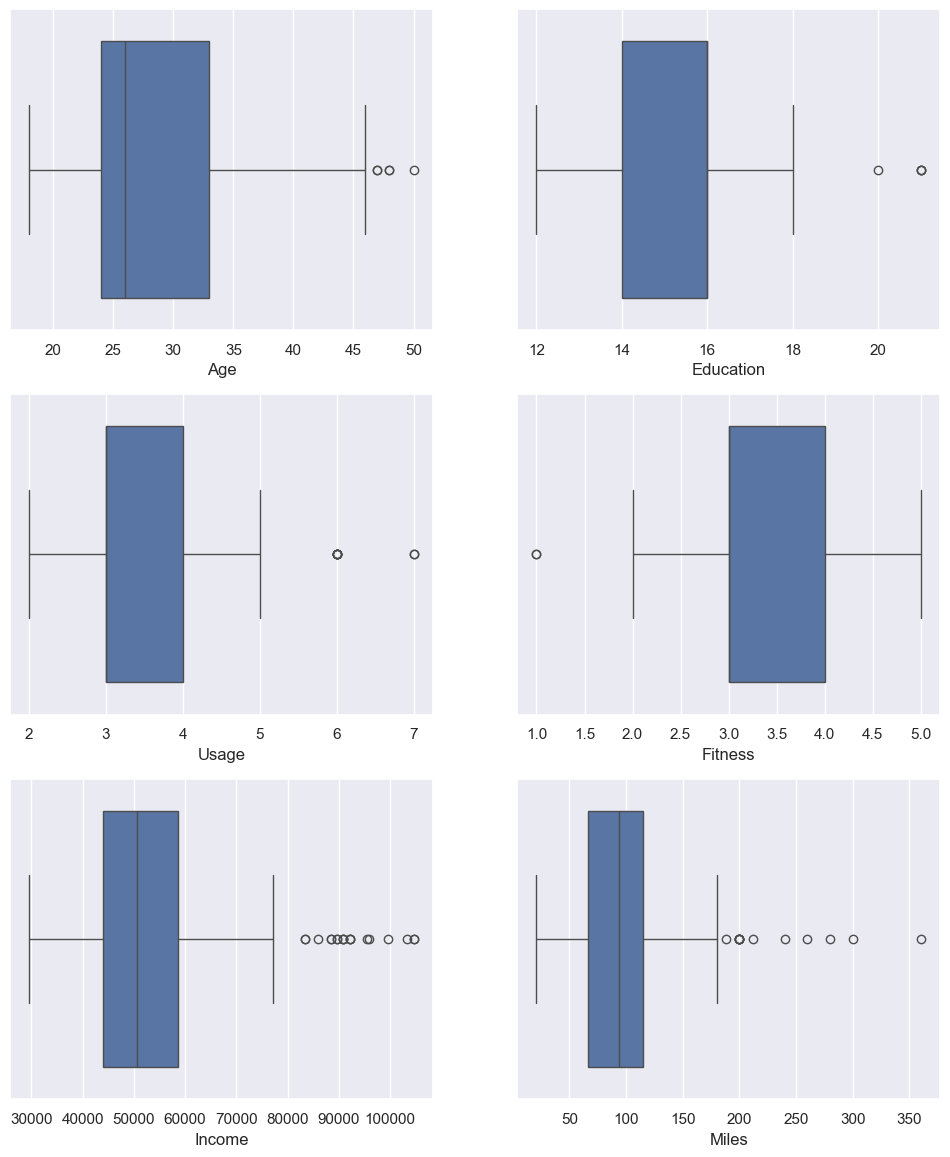

In [70]:
fig, axis = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.subplots_adjust(top=1.2)

sns.boxplot(data=aerofit_df, x="Age", orient='h', ax=axis[0,0])
sns.boxplot(data=aerofit_df, x="Education", orient='h', ax=axis[0,1])
sns.boxplot(data=aerofit_df, x="Usage", orient='h', ax=axis[1,0])
sns.boxplot(data=aerofit_df, x="Fitness", orient='h', ax=axis[1,1])
sns.boxplot(data=aerofit_df, x="Income", orient='h', ax=axis[2,0])
sns.boxplot(data=aerofit_df, x="Miles", orient='h', ax=axis[2,1])
plt.show()

**Obervation**

- ```Age```, ```Education``` and ```Usage``` are having very few outliers.
- ```Income``` and ```Miles``` are having more outliers.
- Only a few of our customers run more than 180 miles per week

### Outlier Handling for ```Income``` Feature

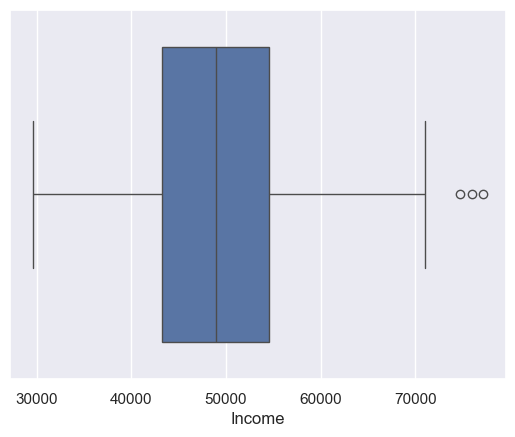

In [71]:
aerofit_df1 = aerofit_df.copy()

Q3 = aerofit_df1['Income'].quantile(0.75)
Q1 = aerofit_df1['Income'].quantile(0.25)
IQR = Q3-Q1
aerofit_df1 = aerofit_df1[(aerofit_df1['Income'] > Q1 - 1.5*IQR) & (aerofit_df1['Income'] < Q3 + 1.5*IQR)]

sns.boxplot(data=aerofit_df1, x="Income", orient='h')
plt.show()

### Outlier Handling for ```Miles``` Feature

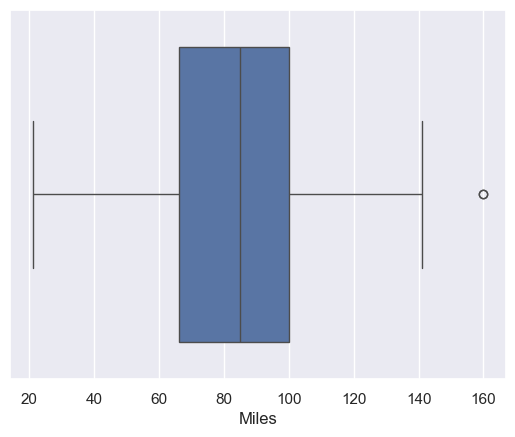

In [72]:
Q3 = aerofit_df1['Miles'].quantile(0.75)
Q1 = aerofit_df1['Miles'].quantile(0.25)
IQR = Q3-Q1
aerofit_df1 = aerofit_df1[(aerofit_df1['Miles'] > Q1 - 1.5*IQR) & (aerofit_df1['Miles'] < Q3 + 1.5*IQR)]

sns.boxplot(data=aerofit_df1, x="Miles", orient='h')
plt.show()

In [73]:
aerofit_df.shape

(180, 9)

In [74]:
aerofit_df1.shape

(147, 9)

While there are outliers, they may provide many insights for high-end models that can benefit companies more. Therefore, they should not be removed for further analysis.

## **Actionable Insights & Recommendations**

### Actionable Insights: 

- Model **KP281** is the **best-selling product**. ```44.0%``` of all treadmill **sales go to model KP281**.

- The majority of treadmill customers fall within the ```$ 45,000``` - ```$ 80,000``` income bracket.
    - 83% of treadmills are bought by individuals with incomes between ```$ 35,000``` and ```$ 85,000```
    
    - There are only ```8%``` of customers with **incomes below $ 35000** who buy treadmills.

- **88%** of treadmills are purchased by **customers aged 20 to 40**.

- **Miles and Fitness** & **Miles and Usage** are highly correlated, which means if a customer's fitness level is high they use more treadmills.

- ***KP781*** is the only model purchased by a customer who has more than 20 years of education and an income of over $ 85,000.

- With **Fitness level 4 and 5**, the customers tend to use **high-end treadmills** and the **average number of miles is above 150 per week**

### Recommendations

- K**P281 & KP481** are popular with customer income of ```$ 45,000``` - ```$ 60,000``` and can be offered by these companies as **affordable models**.

- **KP781** should be marketed as a **Premium Model** and marketing it to **high income groups and educational over 20 years** market segments could result in more sales.

- The **KP781 is a premium model**, so it is ideally suited for **sporty people** who have a high average weekly mileage and can be afforded by the high income customers.

- Aerofit should conduct **market research** to determine if it can attract customers with **income under $ 35,000 to expand its customer base**.